## Image Classification Project Convolutional Neural Network Assignment

In [1]:
# importing libraries
import numpy as np   # Importing required library
import matplotlib.pyplot as plt   # Importing required library

import tensorflow as tf   # Importing required library
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator   # Data augmentation and preprocessing for training/validation images
from tensorflow.keras.models import load_model

In [4]:
from google.colab import drive
drive.mount('/content/drive')   # Mount Google Drive to access datasets/models

In [5]:
# i had zip file of cats_Dogs dataset for that extract zip file
import zipfile   # Importing required library

zip_path = '/content/drive/MyDrive/Cats_Dogs_imgDataset/Cats_Dogs.zip'
extract_path = '/content/dataset'  # Temporary runtime location

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [6]:
import os   # Importing required library

print("Cats:", len(os.listdir('/content/dataset/Cats_Dogs/cats')))
print("Dogs:", len(os.listdir('/content/dataset/Cats_Dogs/dogs')))


Cats: 1000
Dogs: 1000


In [7]:
# Setup
dataset_path = '/content/dataset/Cats_Dogs'
img_height, img_width = 150, 150
batch_size = 32

In [8]:
# Creating image generators with augmentation for training

train_datagen = ImageDataGenerator(   # Data augmentation and preprocessing for training/validation images
    rescale=1./255,
    validation_split=0.2,  # 80/20 split
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)   # Data augmentation and preprocessing for training/validation images


In [9]:
# Load training data

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True
)

Found 1600 images belonging to 2 classes.


In [10]:
# Load validation data

val_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 400 images belonging to 2 classes.


In [11]:
# CNN model building

model = models.Sequential([   # Initializing a Sequential CNN model
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),   # Convolution layer to extract features from images
    layers.MaxPooling2D(2, 2),   # Max pooling to reduce spatial dimensions and computation

    layers.Conv2D(64, (3, 3), activation='relu'),   # Convolution layer to extract features from images
    layers.MaxPooling2D(2, 2),   # Max pooling to reduce spatial dimensions and computation

    layers.Conv2D(128, (3, 3), activation='relu'),   # Convolution layer to extract features from images
    layers.MaxPooling2D(2, 2),   # Max pooling to reduce spatial dimensions and computation

    layers.Flatten(),   # Flattening layer to convert 2D features into 1D vector
    layers.Dense(128, activation='relu'),   # Fully connected (Dense) layer for classification
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # Binary classification: cat or dog  0-1   # Fully connected (Dense) layer for classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# compiling model

model.compile(   # Compiling the model with optimizer, loss function, and metrics
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [13]:
# traing the model
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)  # applied early stopping to avoid overfitting   # Training the model with training data and validating on validation data

history = model.fit(   # Training the model with training data and validating on validation data
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 283ms/step - accuracy: 0.5254 - loss: 0.6929 - val_accuracy: 0.5050 - val_loss: 0.6914
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 227ms/step - accuracy: 0.5071 - loss: 0.6956 - val_accuracy: 0.5125 - val_loss: 0.6899
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 224ms/step - accuracy: 0.5189 - loss: 0.6921 - val_accuracy: 0.5250 - val_loss: 0.6890
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 206ms/step - accuracy: 0.5210 - loss: 0.6891 - val_accuracy: 0.5675 - val_loss: 0.6881
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 229ms/step - accuracy: 0.5342 - loss: 0.6908 - val_accuracy: 0.5875 - val_loss: 0.6876
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 226ms/step - accuracy: 0.5401 - loss: 0.6881 - val_accuracy: 0.5925 - val_loss: 0.6859
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 242ms/step - accuracy: 0.5455 - loss: 0.6870 - val_accuracy: 0.5325 - val_loss: 0.6876
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 228ms/step - accuracy: 0.5431 - loss: 0.6874 - val_accu

###model evaluation

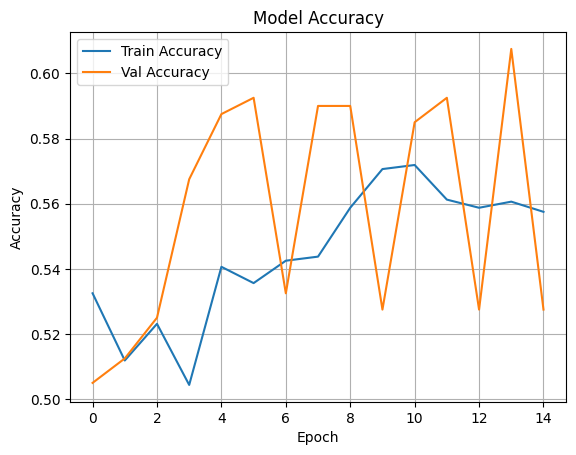

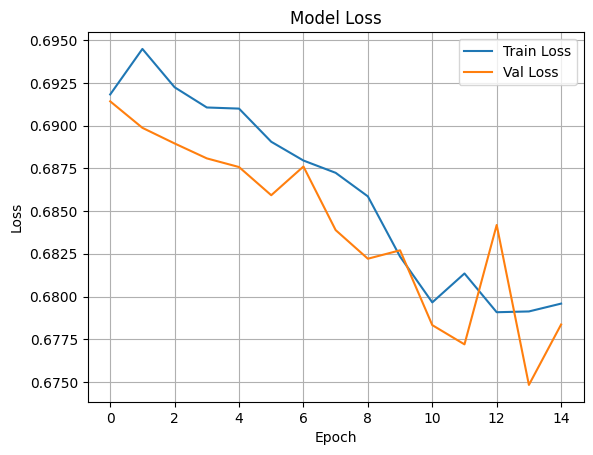

In [14]:
#Plot Accuracy & Loss Curves

import matplotlib.pyplot as plt   # Importing required library

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')   # Plotting results for visualization
plt.plot(history.history['val_accuracy'], label='Val Accuracy')   # Plotting results for visualization
plt.title('Model Accuracy')   # Plotting results for visualization
plt.xlabel('Epoch')   # Plotting results for visualization
plt.ylabel('Accuracy')   # Plotting results for visualization
plt.legend()   # Plotting results for visualization
plt.grid()   # Plotting results for visualization
plt.show()   # Plotting results for visualization

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')   # Plotting results for visualization
plt.plot(history.history['val_loss'], label='Val Loss')   # Plotting results for visualization
plt.title('Model Loss')   # Plotting results for visualization
plt.xlabel('Epoch')   # Plotting results for visualization
plt.ylabel('Loss')   # Plotting results for visualization
plt.legend()   # Plotting results for visualization
plt.grid()   # Plotting results for visualization
plt.show()   # Plotting results for visualization


In [15]:
val_loss, val_acc = model.evaluate(val_generator)   # Evaluating the trained model on test data
print(f"Validation Accuracy: {val_acc:.2f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.4840 - loss: 0.7037
Validation Accuracy: 0.61


### making Prediction on a New Image

In [20]:
from tensorflow.keras.preprocessing import image

# Load image
img_path = '/content/dog.51.jpg'  # new img
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # shape: (1, 150, 150, 3)
img_array /= 255.0  # Normalize

# Predict
prediction = model.predict(img_array)   # Making predictions using the trained model
label = 'DOG🐶' if prediction[0][0] > 0.5 else 'CAT😺'   # Making predictions using the trained model
print(f"Predicted: {label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted: DOG🐶


In [21]:
# saving and exporting models

model.save("cat_dog_model.keras")


In [23]:
import json

class_indices = {"cats": 0, "dogs": 1}

with open("labels.json", "w") as f:
    json.dump(class_indices, f)



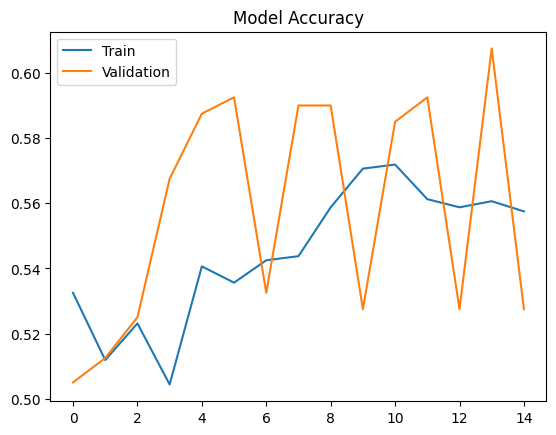

In [24]:
# exporting traning graphs

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train','Validation'])
plt.savefig("accuracy.png")

